# 03 · Operating point, ensemble & calibration
PR-AUC is threshold-free; deployment needs a threshold. For proactive draining a missed failure costs more than a false drain → recall-favoring **F2**.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().resolve().parents[1]  # notebooks/ -> 02_cv_strategies/
sys.path.insert(0, str(ROOT))
import warnings; warnings.filterwarnings('ignore')
import json, numpy as np, pandas as pd
from IPython.display import HTML, display
from cv_strategies import config as C, evaluation_ext as E, report as R
pd.set_option('display.float_format', lambda v: f'{v:.4f}')
print('session folder:', ROOT)

project root: D:\_fcall\UNIFEI\tcc\hpc_workload


### Operating points (best tuned model)

In [2]:
op = pd.read_csv(C.OPERATING_POINTS_CSV); op

,model,operating_point,threshold,precision,recall,f2,flagged,tp,fp,fn,recall_TIMEOUT,recall_FAILED,recall_OOM,recall_NODE_FAIL
0,CatBoost,default@0.5,0.5000,0.0568,0.6269,0.2084,627422,35625,591797,21206,0.6100,0.5860,0.9749,0.8829
1,CatBoost,target_recall@0.80,0.3812,0.0456,0.8191,0.1865,1020369,46551,973818,10280,0.8096,0.8082,1.0000,0.9111
2,CatBoost,best_F2,0.5420,0.0618,0.5597,0.2143,514816,31808,483008,25023,0.5557,0.4701,0.9089,0.8591


### Ensemble of the tuned top-3

In [3]:
pd.read_csv(C.ENSEMBLE_CALIB_CSV)

,name,kind,test_pr_auc,test_roc_auc,recall_global,recall_TIMEOUT,recall_FAILED,recall_OOM,recall_NODE_FAIL,base_pr_auc,note
0,LightGBM,tuned_single,0.0782,0.6266,0.5470,0.5480,0.4956,0.8405,0.6083,0.0793,NaN
1,CatBoost,tuned_single,0.0860,0.6259,0.6269,0.6100,0.5860,0.9749,0.8829,0.0795,NaN
2,HistGradientBoostingClassifier,tuned_single,0.0699,0.6194,0.6259,0.6272,0.5404,0.8825,0.8798,0.0752,NaN
3,Ensemble_mean,ensemble,0.0840,0.6296,0.5845,0.5841,0.4921,0.8656,0.8857,NaN,LightGBM+CatBoost+HistGradientBoostingClassifier
4,Ensemble_rankmean,ensemble,0.0818,0.6298,0.6675,0.6596,0.6076,0.9460,0.9214,NaN,LightGBM+CatBoost+HistGradientBoostingClassifier


### Calibration — Brier improves, PR-AUC is unchanged (monotonic map)

raw       Brier=0.27619  PR-AUC=0.0823
isotonic  Brier=0.04046  PR-AUC=0.0702
sigmoid   Brier=0.03839  PR-AUC=0.0823



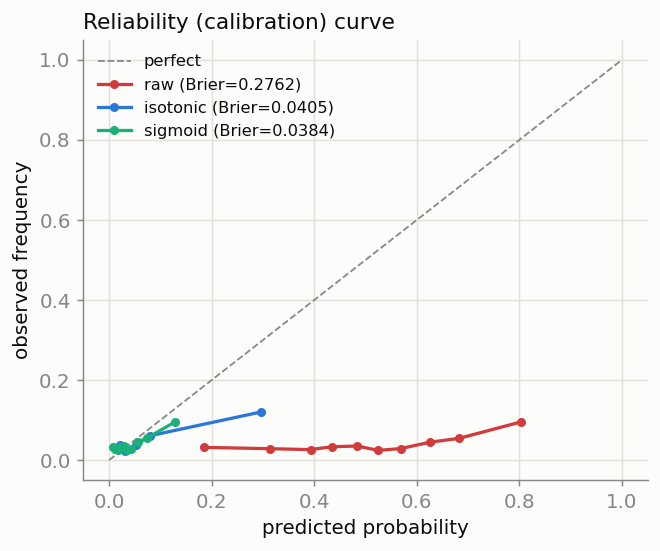

In [4]:
cal = json.loads((C.RESULTS_DIR/'calibration.json').read_text())
for k in ('raw','isotonic','sigmoid'): print(f"{k:<9} Brier={cal[k]['brier']:.5f}  PR-AUC={cal[k]['pr_auc']:.4f}")
display(HTML(f'<img src="{R.fig_reliability(cal)}">'))

**Takeaway.** The F2 threshold turns the ranking score into an actionable drain policy; calibration makes the probability behind that threshold trustworthy.